# 🐄 Smart Magnetic Septum Clamp — Livestock Health Monitor
### ML Pipeline: Synthetic Data Generation → Feature Engineering → Disease Detection

**Sensors on device (4 total):**
- `mq135_ppm` — MQ-135: Ammonia + VOC combined signal (respiratory, metabolic)
- `mq4_ppm` — MQ-4: Methane (rumen fermentation, digestive health)
- `ir_temp_c` — IR Thermometer: Nasal breath temperature (fever, infection)
- `saliva_conductivity` — Conductivity electrodes: Saliva acidity & electrolytes

**Target conditions:** Healthy | Ketosis | Ruminal_Imbalance | Respiratory_Infection | Dehydration

In [8]:
import micropip
await micropip.install("seaborn")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries loaded')

Libraries loaded


## 1. Synthetic Data Generation

In [10]:
def generate_condition(condition, n=400):
    if condition == 'Healthy':
        mq135, mq4, ir_temp, saliva = (np.random.normal(35,5,n), np.random.normal(120,15,n),
                                        np.random.normal(38.5,0.3,n), np.random.normal(5.0,0.3,n))
    elif condition == 'Ketosis':
        # Elevated acetone/ammonia on MQ-135; reduced methane; acidic saliva
        mq135, mq4, ir_temp, saliva = (np.random.normal(78,10,n), np.random.normal(88,20,n),
                                        np.random.normal(38.2,0.4,n), np.random.normal(4.4,0.4,n))
    elif condition == 'Ruminal_Imbalance':
        # Very high methane; very acidic saliva (ruminal acidosis)
        mq135, mq4, ir_temp, saliva = (np.random.normal(50,8,n), np.random.normal(205,30,n),
                                        np.random.normal(38.6,0.4,n), np.random.normal(3.7,0.5,n))
    elif condition == 'Respiratory_Infection':
        # High MQ-135 from infection metabolites; fever
        mq135, mq4, ir_temp, saliva = (np.random.normal(97,12,n), np.random.normal(100,20,n),
                                        np.random.normal(40.3,0.5,n), np.random.normal(5.2,0.4,n))
    elif condition == 'Dehydration':
        # Concentrated electrolytes = very high conductivity
        mq135, mq4, ir_temp, saliva = (np.random.normal(44,8,n), np.random.normal(108,15,n),
                                        np.random.normal(39.2,0.4,n), np.random.normal(8.6,0.6,n))
    return pd.DataFrame({
        'mq135_ppm':          np.clip(mq135, 0, None),
        'mq4_ppm':            np.clip(mq4, 0, None),
        'ir_temp_c':          np.clip(ir_temp, 35, 43),
        'saliva_conductivity': np.clip(saliva, 0, None),
        'condition':          condition
    })

conditions = ['Healthy','Ketosis','Ruminal_Imbalance','Respiratory_Infection','Dehydration']
data = pd.concat([generate_condition(c) for c in conditions], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Dataset: {data.shape}')
print(data['condition'].value_counts())

Dataset: (2000, 5)
condition
Dehydration              400
Healthy                  400
Respiratory_Infection    400
Ruminal_Imbalance        400
Ketosis                  400
Name: count, dtype: int64


## 2. Exploratory Data Analysis

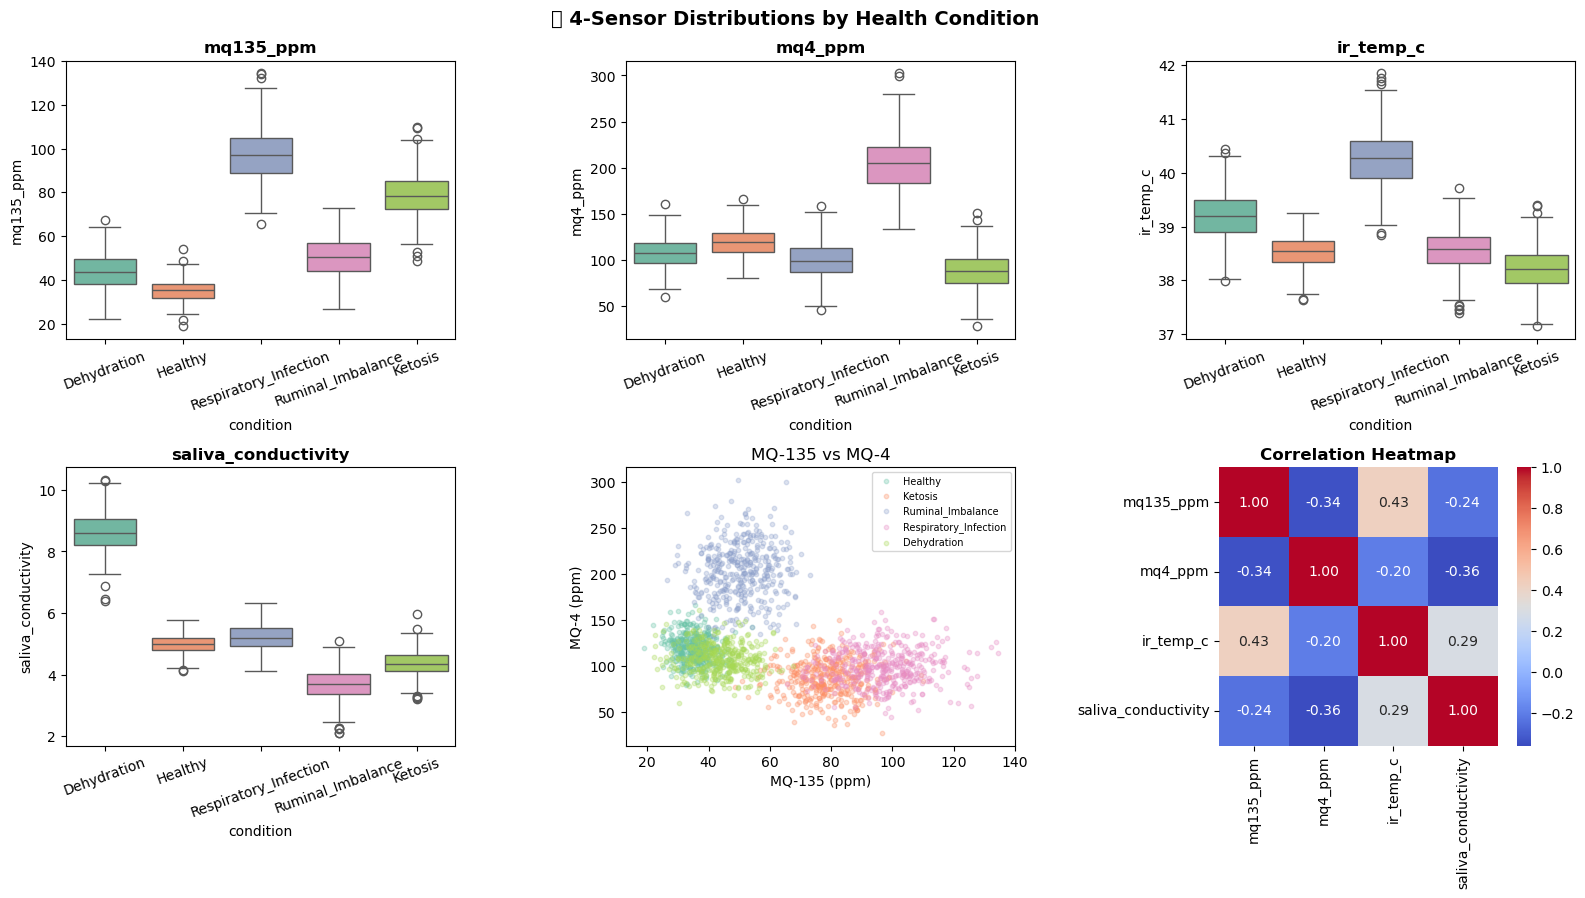

In [11]:
features = ['mq135_ppm','mq4_ppm','ir_temp_c','saliva_conductivity']
palette  = sns.color_palette('Set2', n_colors=5)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=data, x='condition', y=feat, ax=axes[i], palette=palette)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

for cond, color in zip(conditions, palette):
    sub = data[data['condition']==cond]
    axes[4].scatter(sub['mq135_ppm'], sub['mq4_ppm'], alpha=0.3, label=cond, color=color, s=10)
axes[4].set(xlabel='MQ-135 (ppm)', ylabel='MQ-4 (ppm)', title='MQ-135 vs MQ-4')
axes[4].legend(fontsize=7)

sns.heatmap(data[features].corr(), ax=axes[5], annot=True, fmt='.2f', cmap='coolwarm', square=True)
axes[5].set_title('Correlation Heatmap', fontweight='bold')

plt.suptitle('🐄 4-Sensor Distributions by Health Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [12]:
def engineer_features(df):
    df = df.copy()
    df['ammonia_methane_ratio'] = df['mq135_ppm'] / (df['mq4_ppm'] + 1e-6)  # ketosis vs rumen
    df['fever_index']           = (df['ir_temp_c'] - 38.5).abs()             # temp deviation
    df['dehydration_proxy']     = df['saliva_conductivity'] * df['ir_temp_c'] # concentrated + hot
    df['metabolic_stress']      = df['mq135_ppm'] / (df['saliva_conductivity'] + 1e-6) # ketosis
    return df

data_fe = engineer_features(data)
print('Engineered features:', [c for c in data_fe.columns if c not in data.columns])

Engineered features: ['ammonia_methane_ratio', 'fever_index', 'dehydration_proxy', 'metabolic_stress']


## 4. Model Training — Random Forest + Gradient Boosting

In [14]:
feature_cols = ['mq135_ppm','mq4_ppm','ir_temp_c','saliva_conductivity',
                'ammonia_methane_ratio','fever_index','dehydration_proxy','metabolic_stress']

X = data_fe[feature_cols]
y = data_fe['condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_pipeline = Pipeline([('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))])
gb_pipeline = Pipeline([('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42))])

rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)

rf_cv = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy').mean()
gb_cv = cross_val_score(gb_pipeline, X, y, cv=5, scoring='accuracy').mean()
print(f'Random Forest     CV Accuracy: {rf_cv:.4f}')
print(f'Gradient Boosting CV Accuracy: {gb_cv:.4f}')

Random Forest     CV Accuracy: 0.9955
Gradient Boosting CV Accuracy: 0.9940


## 5. Evaluation

In [15]:
best_model = rf_pipeline if rf_cv >= gb_cv else gb_pipeline
best_name  = 'Random Forest' if rf_cv >= gb_cv else 'Gradient Boosting'
y_pred = best_model.predict(X_test)
print(f'Best Model: {best_name}\n')
print(classification_report(y_test, y_pred))

Best Model: Random Forest

                       precision    recall  f1-score   support

          Dehydration       1.00      1.00      1.00        80
              Healthy       1.00      0.99      0.99        80
              Ketosis       0.98      1.00      0.99        80
Respiratory_Infection       1.00      0.99      0.99        80
    Ruminal_Imbalance       1.00      1.00      1.00        80

             accuracy                           0.99       400
            macro avg       1.00      0.99      1.00       400
         weighted avg       1.00      0.99      1.00       400



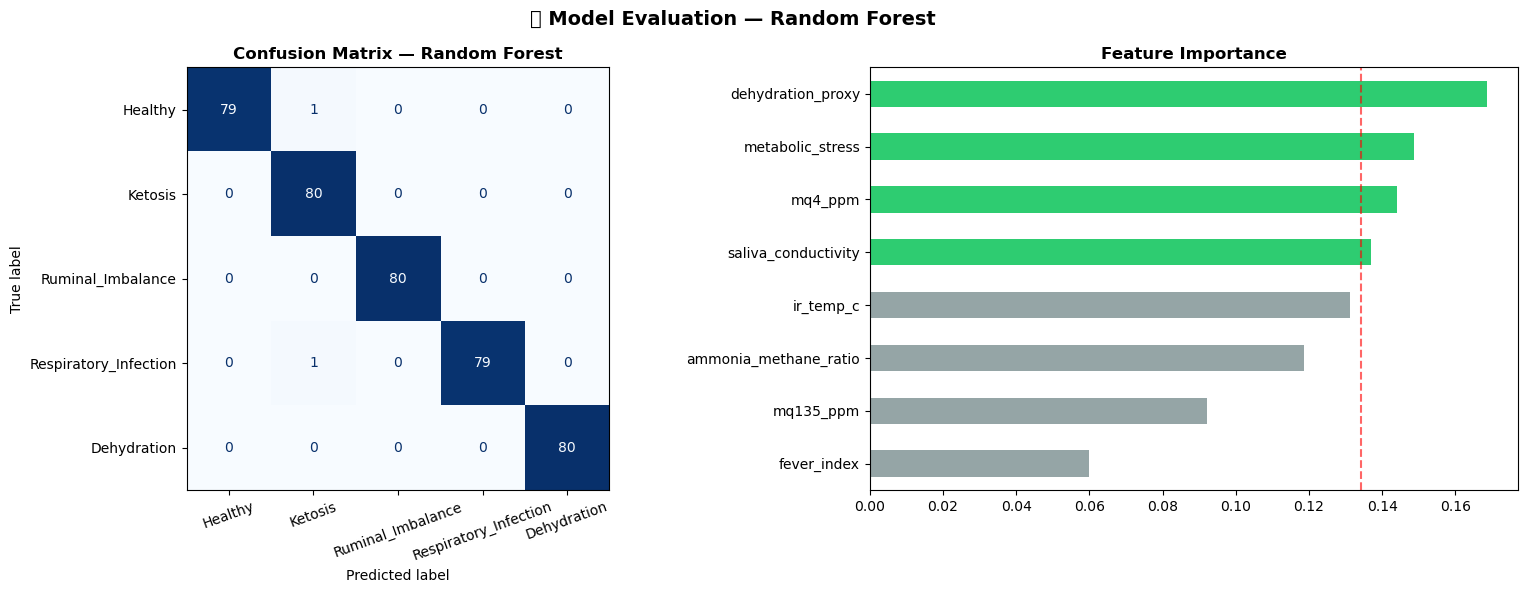

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_test, y_pred, labels=conditions)
ConfusionMatrixDisplay(cm, display_labels=conditions).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

clf = best_model.named_steps['clf']
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
colors = ['#2ecc71' if v > importances.median() else '#95a5a6' for v in importances]
importances.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].axvline(importances.median(), color='red', linestyle='--', alpha=0.6)

plt.suptitle(f'🐄 Model Evaluation — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Real-Time Inference Simulator

In [17]:
def predict_health(mq135, mq4, ir_temp, saliva_cond):
    raw = pd.DataFrame([{'mq135_ppm':mq135,'mq4_ppm':mq4,'ir_temp_c':ir_temp,'saliva_conductivity':saliva_cond}])
    sample = engineer_features(raw)[feature_cols]
    pred  = best_model.predict(sample)[0]
    proba = best_model.predict_proba(sample)[0]

    print(f'Sensor Input: MQ135={mq135}ppm  MQ4={mq4}ppm  Temp={ir_temp}C  Saliva={saliva_cond}mS/cm')
    print(f'Predicted: {pred}')
    for cls, prob in sorted(zip(best_model.classes_, proba), key=lambda x:-x[1]):
        print(f'  {cls:<25} {"#"*int(prob*30)} {prob:.1%}')
    alerts = {
        'Healthy':               'No action needed.',
        'Ketosis':               'ALERT: Check energy intake. Propylene glycol supplement.',
        'Ruminal_Imbalance':     'ALERT: Review feed. Check rumen pH. Consult vet.',
        'Respiratory_Infection': 'URGENT: Fever! Isolate animal. Vet exam required.',
        'Dehydration':           'ALERT: Increase water. Check electrolyte balance.'
    }
    print(f'Action: {alerts.get(pred)}\n')

predict_health(33, 118, 38.4, 5.1)   # healthy
predict_health(96, 102, 40.5, 5.3)   # respiratory
predict_health(80, 85,  38.1, 4.3)   # ketosis
predict_health(46, 109, 39.3, 8.8)   # dehydration

Sensor Input: MQ135=33ppm  MQ4=118ppm  Temp=38.4C  Saliva=5.1mS/cm
Predicted: Healthy
  Healthy                   ############################## 100.0%
  Dehydration                0.0%
  Ketosis                    0.0%
  Respiratory_Infection      0.0%
  Ruminal_Imbalance          0.0%
Action: No action needed.

Sensor Input: MQ135=96ppm  MQ4=102ppm  Temp=40.5C  Saliva=5.3mS/cm
Predicted: Respiratory_Infection
  Respiratory_Infection     ############################## 100.0%
  Dehydration                0.0%
  Healthy                    0.0%
  Ketosis                    0.0%
  Ruminal_Imbalance          0.0%
Action: URGENT: Fever! Isolate animal. Vet exam required.

Sensor Input: MQ135=80ppm  MQ4=85ppm  Temp=38.1C  Saliva=4.3mS/cm
Predicted: Ketosis
  Ketosis                   ############################## 100.0%
  Dehydration                0.0%
  Healthy                    0.0%
  Respiratory_Infection      0.0%
  Ruminal_Imbalance          0.0%
Action: ALERT: Check energy intake. P

## 7. Save Model

In [18]:
import pickle
with open('livestock_health_model.pkl','wb') as f:
    pickle.dump({'model':best_model,'feature_cols':feature_cols,'conditions':conditions,'name':best_name}, f)
print(f'Model saved: livestock_health_model.pkl  ({best_name}, {len(feature_cols)} features)')
print('Ready for farm dashboard or embedded deployment.')

Model saved: livestock_health_model.pkl  (Random Forest, 8 features)
Ready for farm dashboard or embedded deployment.
